# MSE 5720 Assignment 2  
**Haichuan Zhang**  
📧 *hz738@cornell.edu*  

##### All shell scripts, original input files, and output files can be found in the GitHub repository: https://github.com/chemerzhc/Cornell-MSE5720-Assignment.
---

## Introduction  



## Exercise 1: Calculation of the density of states and electronic band structure

### Exercise 1A

Calculate the band structure and density of states for Si using the procedure described above. Prepare plots of the total density of states, and the density of states for each kind of orbital (s, p, d). Assign peaks in the total density of states to atoms/orbitals using information from the atom- and orbital-resolved densities of states. Prepare your plots such that the highest occupied energy level is set to zero energy. What is the chemical character of the valence and conduction bands in Si? Compare your calculated band structure with results from other DFT calculations in the literature. Hint: it may be easier to first locate the relevant papers in the literature and then prepare your band structure plot using the same path through the Brilloiun zone. Hence, you may need to change the information in the K POINTS block in the ’bands’ part of the calculation.

#### Optimal partameters

To begin with, we first test the wave energy cutoff and k point considering the convergence of energy following the procedure of HW1. Similar to HW1, I also obtain the .out files from ESPRESSO using wget from online. The energy cutoff is changed from 20 to 100 Ry and the k point is changed from 2 to 12. Then the optimized lattice constant is calculated using bfgs in ESPRESSO. Taking the same criteria from HW1 as using 5meV for total energy difference, the converged energy cutoff is considered as**40 Ry**, and converged k points is **8**. The optimized lattice constant is **10.205 bohr**.

In [56]:
import os
import re
import requests
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [57]:
cutoffs = list(range(20, 101, 10))  # 20, 30, ..., 100
print(cutoffs)
energies = []
energy_pattern = re.compile(r"[! ]\s*total energy\s*=\s*(-?\d+\.\d+)")

[20, 30, 40, 50, 60, 70, 80, 90, 100]


In [58]:
for cutoff in cutoffs:
    url = (
        f"https://raw.githubusercontent.com/"
        f"chemerzhc/Cornell-MSE5720-Assignment/"
        f"main/HW2/Q1/A_Pre_Cal/energycutoff/si_{cutoff}/Si_{cutoff}.out"
    )

    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        energies.append(None)
        continue

    content = response.text
    match = energy_pattern.search(content)
    if match:
        energy = float(match.group(1))
        energies.append(energy)
        print(f"Cutoff {cutoff}: Energy = {energy:.8f} Ry")
    else:
        print(f"⚠️ No energy found in {url}")
        energies.append(None)

print("\nEnergies collected:")
for cutoff, energy in zip(cutoffs, energies):
    print(f"ecutwfc = {cutoff} Ry → total energy = {energy}")

Cutoff 20: Energy = -19.25618939 Ry
Cutoff 30: Energy = -19.25687729 Ry
Cutoff 40: Energy = -19.25699355 Ry
Cutoff 50: Energy = -19.25702285 Ry
Cutoff 60: Energy = -19.25704498 Ry
Cutoff 70: Energy = -19.25705342 Ry
Cutoff 80: Energy = -19.25706924 Ry
Cutoff 90: Energy = -19.25708139 Ry
Cutoff 100: Energy = -19.25708212 Ry

Energies collected:
ecutwfc = 20 Ry → total energy = -19.25618939
ecutwfc = 30 Ry → total energy = -19.25687729
ecutwfc = 40 Ry → total energy = -19.25699355
ecutwfc = 50 Ry → total energy = -19.25702285
ecutwfc = 60 Ry → total energy = -19.25704498
ecutwfc = 70 Ry → total energy = -19.25705342
ecutwfc = 80 Ry → total energy = -19.25706924
ecutwfc = 90 Ry → total energy = -19.25708139
ecutwfc = 100 Ry → total energy = -19.25708212


cutoffs: 9 [20, 30, 40, 50, 60, 70, 80, 90, 100]
energies: 9 [-19.25618939, -19.25687729, -19.25699355, -19.25702285, -19.25704498, -19.25705342, -19.25706924, -19.25708139, -19.25708212]


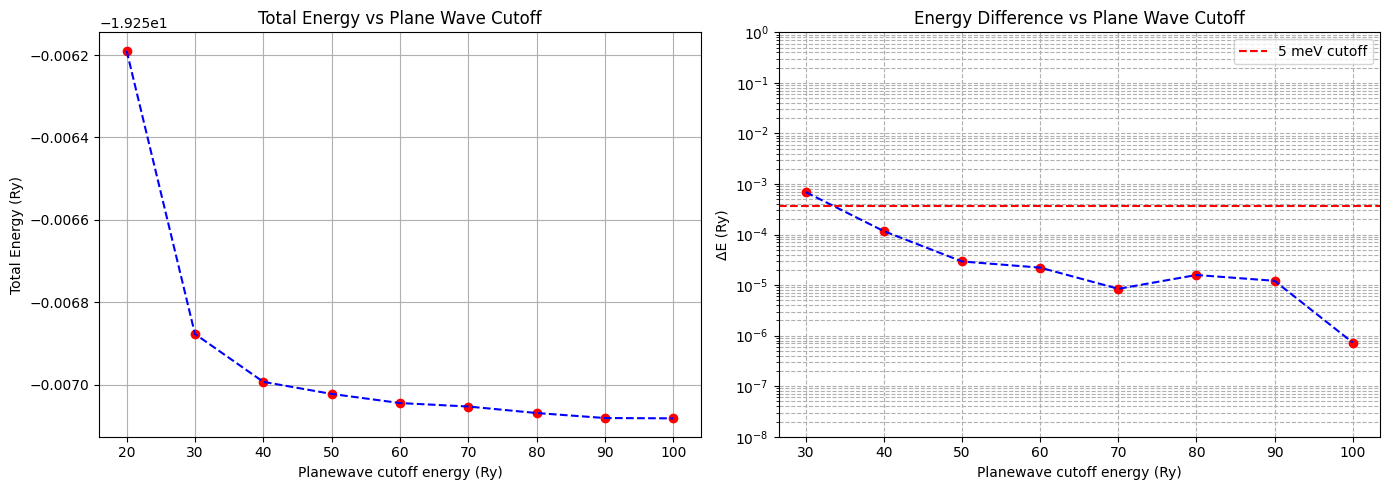

In [59]:
delta_energies = []
for i in range(len(energies)):
    if i == 0 or energies[i] is None or energies[i-1] is None:
        delta_energies.append(None)
    else:
        delta_energies.append(abs(energies[i] - energies[i-1]))
print("cutoffs:", len(cutoffs), cutoffs)
print("energies:", len(energies), energies)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, energies, 'ro')
axes[0].plot(cutoffs, energies, linestyle='--', color='blue')
axes[0].set_xlabel("Planewave cutoff energy (Ry)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs Plane Wave Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_energies, 'ro')
axes[1].plot(cutoffs, delta_energies, linestyle='--', color='blue')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")  # Ry to meV by 13.6
axes[1].set_xlabel("Planewave cutoff energy (Ry)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs Plane Wave Cutoff")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-8, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

In [117]:
ks = list(range(2, 13))
energies = []
num_kpoints = []
print(ks)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [125]:
forces = []
force_pattern = re.compile(r"Total force\s*=\s*([0-9.]+)")
kpoint_pattern = re.compile(r"number of k points\s*=\s*(\d+)")

In [126]:
for k in range(2, 13):
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/A_Pre_Cal/kpoints/si_k{k}/Si_k{k}.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        forces.append(None)
        continue

    content = response.text
    match = force_pattern.search(content)
    if match:
        force = float(match.group(1))
        forces.append(force)
        print(f"K-point {k}: Total force = {force}")
    else:
        print(f"⚠️ No total force found in {url}")
        forces.append(None)

K-point 2: Total force = 0.075165
K-point 3: Total force = 0.063293
K-point 4: Total force = 0.059895
K-point 5: Total force = 0.058633
K-point 6: Total force = 0.058131
K-point 7: Total force = 0.057922
K-point 8: Total force = 0.057831
K-point 9: Total force = 0.05779
K-point 10: Total force = 0.057769
K-point 11: Total force = 0.057759
K-point 12: Total force = 0.057753


[None, 0.011871999999999994, 0.003398000000000005, 0.0012619999999999992, 0.0005019999999999955, 0.00020900000000000085, 9.10000000000008e-05, 4.099999999999937e-05, 2.1000000000000185e-05, 1.0000000000003062e-05, 5.999999999999062e-06]


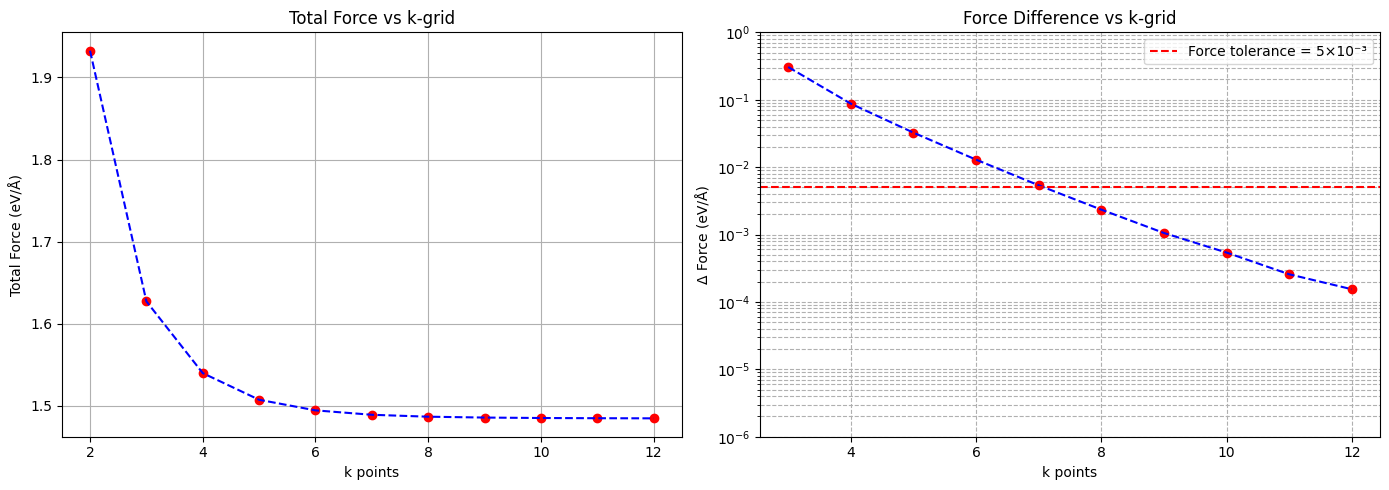

In [127]:
delta_forces = []
for i in range(len(forces)):
    if i == 0 or forces[i] is None or forces[i-1] is None:
        delta_forces.append(None)
    else:
        delta_forces.append(abs(forces[i] - forces[i-1]))

print(delta_forces)
import numpy as np
forces = np.array(forces, dtype=float)
delta_forces = np.array(delta_forces, dtype=float)
factor = 13.605693 /0.529177
forces *= factor
delta_forces *= factor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ks, forces, 'ro')
axes[0].plot(ks, forces, linestyle='--', color='blue')
axes[0].set_xlabel("k points")
axes[0].set_ylabel("Total Force (eV/Å)")
axes[0].set_title("Total Force vs k-grid")
axes[0].grid(True)

axes[1].plot(ks, delta_forces, 'ro')
axes[1].plot(ks, delta_forces, linestyle='--', color='blue')
axes[1].axhline(5e-3, color='r', linestyle='--', label="Force tolerance = 5×10⁻³")
axes[1].set_xlabel("k points")
axes[1].set_ylabel("Δ Force (eV/Å)")
axes[1].set_title("Force Difference vs k-grid")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-6, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

Changing the calculation methods from **scf** to **vc-relax**, and following the same procedure in HW1, the optimized lattice constant is obtained from bfgs.

The optimized lattice constant is 10.205 Ry. According to NIST, the lattice constant for silicon is **10.2646 Bohr**, our converged value has a relative error of **0.62%**
.

### Band structure

Followed, the band structures are computed from ESPRESSO. Following the procedure given, I change the command to ibrav=0 and modify the KPOINTS path to

K_POINTS crystal_b 

3

0.5d0 0.5d0 0.5d0 20

0.d0 0.d0 0.d0 20

1.d0 0.d0 0.d0 20



In [64]:
url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/bands/bands/Si.bandsplot.gnu"
response = requests.get(url)
if response.status_code != 200:
    raise RuntimeError(f"Failed to fetch data: {url}")

content = response.text.strip()

bands_raw = content.split("\n\n")

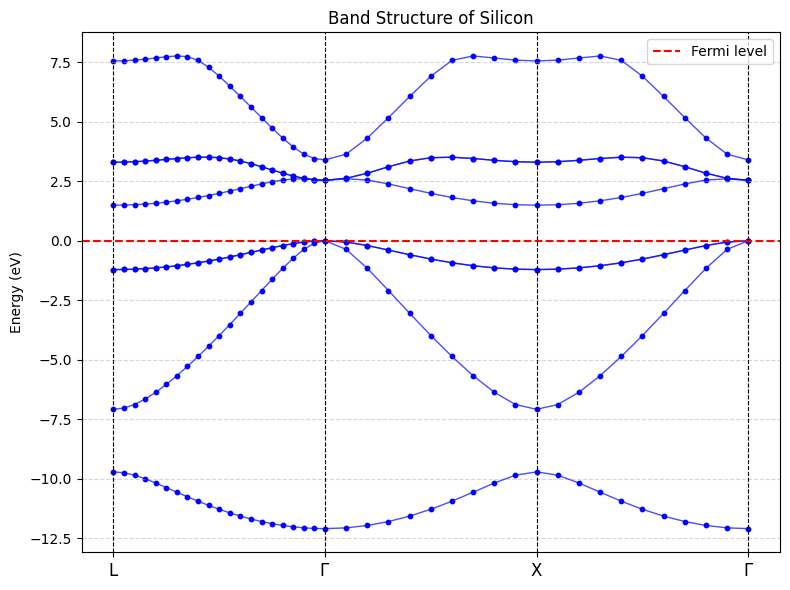

In [141]:
E_F = 6.2002
bands = []
for band in bands_raw:
    data = np.loadtxt(band.splitlines())
    k = data[:, 0]
    e = data[:, 1] - E_F
    bands.append((k, e))

plt.figure(figsize=(8, 6))

def find_breaks(k_paths):
    breaks = []
    for i in range(1, len(k_paths[0])):
        if abs(k_paths[0][i] - k_paths[0][i-1]) > 0.1:
            breaks.append(i)
    return breaks

breaks = find_breaks([k for k, e in bands])

for k, e in bands:
    start_idx = 0
    for break_idx in breaks:
        end_idx = break_idx
        plt.scatter(k[start_idx:end_idx], e[start_idx:end_idx], s=10, color='blue')
        plt.plot(k[start_idx:end_idx], e[start_idx:end_idx], color='blue', linewidth=1, alpha=0.7)
        start_idx = end_idx

    plt.scatter(k[start_idx:], e[start_idx:], s=10, color='blue')
    plt.plot(k[start_idx:], e[start_idx:], color='blue', linewidth=1, alpha=0.7)

plt.axhline(0, color='red', linestyle='--', label='Fermi level')

high_sym_points = [0, 0.86603, 1.73206, 2.5981] 
labels = ['L', r'$\Gamma$', 'X', r'$\Gamma$']

for x in high_sym_points:
    plt.axvline(x, color='black', linestyle='--', linewidth=0.8)

plt.xticks(high_sym_points, labels, fontsize=12)

plt.xlabel('')
plt.ylabel("Energy (eV)")
plt.title("Band Structure of Silicon")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


The overall features and trends agree well with the reference. If compared with the band structure reported by Niquet et al. (2009), one can observe that along the path $Γ \rightarrow X \rightarrow W \rightarrow L \rightarrow Γ$ (corresponding to the full horizontal axis in my figure), the general characteristics of the band dispersion are well reproduced.

<img src="https://www.researchgate.net/profile/Yann-Michel-Niquet/publication/23970403/figure/fig1/AS:671534309982215@1537117664390/Color-online-Band-structure-of-bulk-unstrained-silicon-in-the-sp-3-d-5-s-TB-and-GW.png" alt="drawing" height="600"/>

#### Density of states

The density of states (DOS) and projected DOS (PDOS) are obtained through DFT calculation of ```&DOS``` and ```&PROJWFC``` using the commands ```dos.x``` and ```projwfc.x```, respectively. The output files are obtained through ```wget``` and the visualization method are partially adopted from [Dr. Das](https://pranabdas.github.io/espresso/).

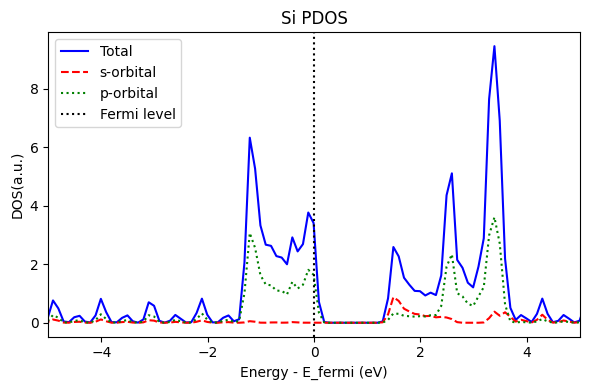

In [131]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/bands/bands/si_pdos.txt"
filename = "si_pdos.txt"
urllib.request.urlretrieve(url, filename)

data = np.loadtxt(filename, skiprows=1)

E = data[:,0]         
dos_total = data[:,1] 
ldos1 = data[:,2]     
ldos2 = data[:,3]    

E_fermi = 6.22
E_shifted = E - E_fermi

plt.figure(figsize=(6,4))
plt.plot(E_shifted, dos_total, label='Total', color='blue')
plt.plot(E_shifted, ldos1, label='s-orbital', color='red', linestyle='--')
plt.plot(E_shifted, ldos2, label='p-orbital', color='green', linestyle=':')
plt.axvline(0, color='k', linestyle=':', label='Fermi level')  # 标出费米能级
plt.xlabel("Energy - E_fermi (eV)")
plt.ylabel("DOS(a.u.)")
plt.title("Si PDOS")
plt.xlim(-5, 5)
plt.legend()
plt.tight_layout()
plt.show()


To verify the accurate calculation of PDOS, a reference figure is obtained from [plotly](https://plotly.com/python/v3/ipython-notebooks/density-of-states/), made by [Prof. Vallverdu](https://gvallver.perso.univ-pau.fr/), shown as below:

<img src="https://plotly.com/~gvallverdu/306/bands-diagram-and-density-of-states-of-silicon.png" alt="drawing" height="450"/>

In the projected density of states (PDOS) obtained for Si, a slight overlap of some energy levels with the Fermi level is observed. This feature is likely due to the relatively sparse k-point sampling along the KPATH in my calculation. In contrast, literature results with denser k-point grids yield smoother PDOS curves. Hence, the sharpness of my PDOS mainly reflects computational parameters rather than physical differences.

From the PDOS analysis, the valence band is primarily dominated by p orbitals, with minor contributions from s orbitals, whereas the conduction band consists of both s and p orbitals, and d orbital contributions are negligible. This orbital character is consistent with previous DFT results (e.g., Singh et al., 2013; Niquet et al., 2009), indicating that the calculation captures the main chemical characteristics of Si.

By mapping the peaks in the total DOS to specific orbitals, it is clear that the valence band peaks near the Fermi level originate mainly from p orbitals, while the high-energy conduction band peaks involve both s and p orbitals. This distribution is consistent with the electronic structure of a semiconductor. Overall, my calculated band structure and DOS are in good agreement with literature DFT results, with deviations primarily due to k-point sampling density and the well-known LDA underestimation of the bandgap.

### Exercise 1B

*What is the band gap for Si? Is Si a direct or indirect gap insulator? How does your gap compare with experiment, and with other DFT calculations in the literature?*

There are many ways to obtain the band gap from DFT. Here, I examine two of which to test my results either directly extracted from the energy difference from the ```.out``` file, or plot the DOS and compute the length of the "zero value regime". 

```highest occupied, lowest unoccupied level (ev):     6.1993    6.6428```

Hence, the band gap obtained from the DFT band structure is approximately 0.45 eV. A second approach to estimate the band gap is by measuring the width of the “zero-value region” in the DOS plot; using this method, the computed band gap is 0.61 eV.

Since the Fermi level lies within the bandgap for silicon, it confirms the semiconducting nature of the material. Compared with the reference data from Singh et al. (2013), where the LDA-calculated band gap of silicon is 0.49 eV, our result differs by only 6.12%, which is an acceptable deviation. However, the experimentally measured band gap is 1.12 eV, indicating that LDA significantly underestimates the bandgap. As discussed by Persson and Mirbt (2006), “if the electron–electron repulsion within LDA is too strong, the electron wavefunction overlap becomes too small, and consequently, the semiconductor band gap is underestimated.” This explanation is consistent with our computational findings for silicon.

### Exercise 1C

*Examine the DOS for bulk Si and Si doped with Au in Figure 2 (from [Sholl & Steckel, 2009](https://onlinelibrary.wiley.com/doi/book/10.1002/9780470447710)). Pay particular attention to the DOS at the band gap. Now read [Nature Materials 4 676 (2005)](https://www.nature.com/articles/nmat1457). How do you think the presence of Au affects the performance of Si in solar cells?*

From Fig. 2 (HW), two pronounced peaks can be observed at approximately 
𝐸
≈
0
 eV
E≈0 eV and 
𝐸
≈
5
 eV
E≈5 eV in Au-doped Si, compared with pure Si. This indicates that the presence of Au significantly modifies the density of states (DOS) in the bandgap region, resulting in an apparent DOS “peak” within the gap—an electronic feature more characteristic of conductors than semiconductors.

The change in DOS suggests that Au incorporation alters the electronic occupancy in Si, although the overall electrical conductivity does not vary dramatically. According to Buonassisi et al., metal-containing semiconductors can still be acceptable for solar-cell applications, as nanoscale defect engineering can mitigate the detrimental electronic effects of metallic impurities.

Furthermore, the introduction of Au affects the carrier diffusion length, implying that metal-induced defects influence both electron distribution and transport in Si. Combining these observations, we infer that metallic nano-defects modify electron occupancy and carrier diffusion, thereby altering the electronic properties of silicon. Specifically, the Au-induced “bandgap narrowing” leads to a reduction in the efficiency of Si-based solar cells.

### Exercise 1D


In this exercise we will consider the dielectric material BaTiO3. BaTiO3 is an industrially important, electronic ceramic, used to make capacitors for scores of electronic devices. The favorable electronic
properties of BaTiO3 arise directly from hybridization (mixing) between the Ti d states, which are formally
empty and sit at the bottom of the conduction band, and the O p states, which are filled and sit at the top
of the valence band. This mixing should be visible in a DOS plot as an overlap between the Ti d states and
the O p states (in fact, DFT calculations were used to prove the mechanism through which BaTiO3 is such
a useful dielectric!). Calculate the orbital-resolved DOS for BaTiO3 – do you seen an overlap between
these states? You will first need to optimize and converge the lattice parameter with respect to the cutoff
energy and k-point mesh

In [133]:
cutoffs = list(range(30, 101, 10))  # 20, 30, ..., 100
print(cutoffs)
energies = []
energy_pattern = re.compile(r"[! ]\s*total energy\s*=\s*(-?\d+\.\d+)")

[30, 40, 50, 60, 70, 80, 90, 100]


In [134]:
for cutoff in cutoffs:
    url = (
        f"https://raw.githubusercontent.com/"
        f"chemerzhc/Cornell-MSE5720-Assignment/"
        f"main/HW2/Q1/D_Pre_Cal/Q1D_energyoff/Q1D_energyoff/bto_{cutoff}/BTO_{cutoff}.out"
    )

    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        energies.append(None)
        continue

    content = response.text
    match = energy_pattern.search(content)
    if match:
        energy = float(match.group(1))
        energies.append(energy)
        print(f"Cutoff {cutoff}: Energy = {energy:.8f} Ry")
    else:
        print(f"⚠️ No energy found in {url}")
        energies.append(None)

print("\nEnergies collected:")
for cutoff, energy in zip(cutoffs, energies):
    print(f"ecutwfc = {cutoff} Ry → total energy = {energy}")

Cutoff 30: Energy = -286.60179958 Ry
Cutoff 40: Energy = -286.62024856 Ry
Cutoff 50: Energy = -286.62198311 Ry
Cutoff 60: Energy = -286.62266744 Ry
Cutoff 70: Energy = -286.62115724 Ry
Cutoff 80: Energy = -286.61348506 Ry
Cutoff 90: Energy = -286.62051111 Ry
Cutoff 100: Energy = -286.62001962 Ry

Energies collected:
ecutwfc = 30 Ry → total energy = -286.60179958
ecutwfc = 40 Ry → total energy = -286.62024856
ecutwfc = 50 Ry → total energy = -286.62198311
ecutwfc = 60 Ry → total energy = -286.62266744
ecutwfc = 70 Ry → total energy = -286.62115724
ecutwfc = 80 Ry → total energy = -286.61348506
ecutwfc = 90 Ry → total energy = -286.62051111
ecutwfc = 100 Ry → total energy = -286.62001962


cutoffs: 8 [30, 40, 50, 60, 70, 80, 90, 100]
energies: 8 [-286.60179958, -286.62024856, -286.62198311, -286.62266744, -286.62115724, -286.61348506, -286.62051111, -286.62001962]


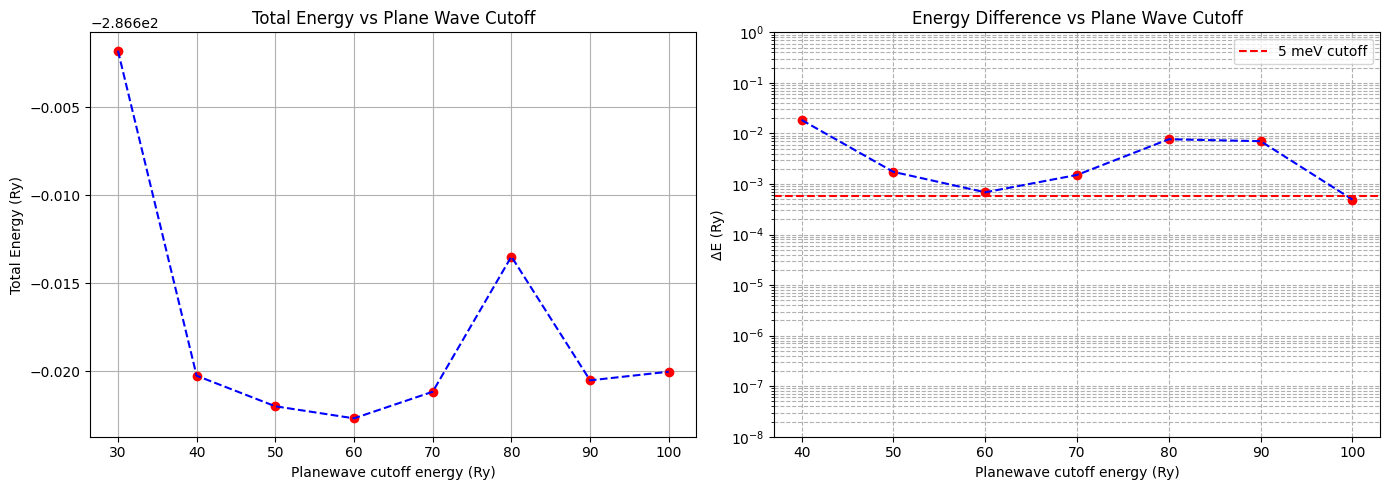

In [138]:
delta_energies = []
for i in range(len(energies)):
    if i == 0 or energies[i] is None or energies[i-1] is None:
        delta_energies.append(None)
    else:
        delta_energies.append(abs(energies[i] - energies[i-1]))
print("cutoffs:", len(cutoffs), cutoffs)
print("energies:", len(energies), energies)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, energies, 'ro')
axes[0].plot(cutoffs, energies, linestyle='--', color='blue')
axes[0].set_xlabel("Planewave cutoff energy (Ry)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs Plane Wave Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_energies, 'ro')
axes[1].plot(cutoffs, delta_energies, linestyle='--', color='blue')
axes[1].axhline(8e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")  # Ry to meV by 13.6
axes[1].set_xlabel("Planewave cutoff energy (Ry)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs Plane Wave Cutoff")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-8, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

In [71]:
ks = list(range(2, 13))
energies = []
num_kpoints = []
print(ks)

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [146]:
forces = []
force_pattern = re.compile(r"Total force\s*=\s*([0-9.]+)")
kpoint_pattern = re.compile(r"number of k points\s*=\s*(\d+)")

In [147]:
for k in range(2, 13):
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/D_Pre_Cal/Q1D_kp/A2Q1D_kp/bto_k{k}/BTO_k{k}.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        forces.append(None)
        continue

    content = response.text
    match = force_pattern.search(content)
    if match:
        force = float(match.group(1))
        forces.append(force)
        print(f"K-point {k}: Total force = {force}")
    else:
        print(f"⚠️ No total force found in {url}")
        forces.append(None)

K-point 2: Total force = 0.079494
K-point 3: Total force = 0.041894
K-point 4: Total force = 0.036431
K-point 5: Total force = 0.035485
K-point 6: Total force = 0.034604
K-point 7: Total force = 0.03472
K-point 8: Total force = 0.034583
K-point 9: Total force = 0.034712
K-point 10: Total force = 0.03458
K-point 11: Total force = 0.034595
K-point 12: Total force = 0.034509


[None, 0.037599999999999995, 0.005463000000000003, 0.0009459999999999955, 0.0008809999999999998, 0.00011599999999999805, 0.00013699999999999823, 0.00012899999999999717, 0.00013200000000000017, 1.5000000000001124e-05, 8.600000000000274e-05]


C:\Users\cheme\AppData\Local\Temp\ipykernel_22452\490984594.py:32: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[1].set_ylim(1e-6, 0)


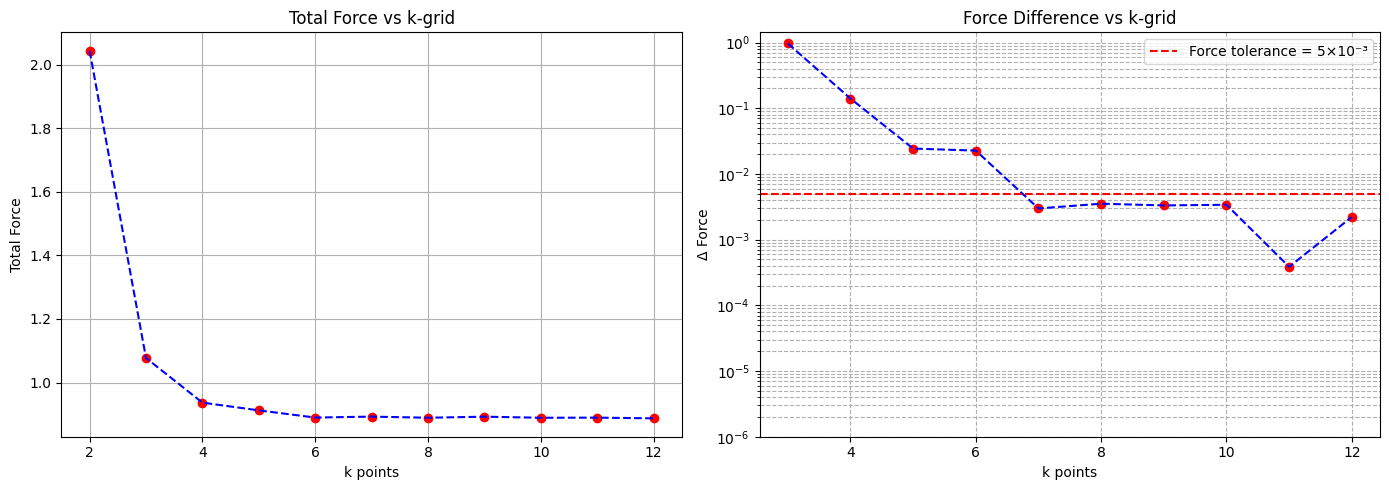

In [ ]:
delta_forces = []
for i in range(len(forces)):
    if i == 0 or forces[i] is None or forces[i-1] is None:
        delta_forces.append(None)
    else:
        delta_forces.append(abs(forces[i] - forces[i-1]))

print(delta_forces)
import numpy as np
forces = np.array(forces, dtype=float)
delta_forces = np.array(delta_forces, dtype=float)
factor = 13.605693 /0.529177
forces *= factor
delta_forces *= factor

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, forces, 'ro')
axes[0].plot(ks, forces, linestyle='--', color='blue')
axes[0].set_xlabel("k points")
axes[0].set_ylabel("Total Force (eV/Å)")
axes[0].set_title("Total Force vs k-grid")
axes[0].grid(True)

axes[1].plot(ks, delta_forces, 'ro')
axes[1].plot(ks, delta_forces, linestyle='--', color='blue')
axes[1].axhline(5e-3, color='r', linestyle='--', label="Force tolerance = 5×10⁻³")
axes[1].set_xlabel("k points")
axes[1].set_ylabel("Δ Force (eV/Å)")
axes[1].set_title("Force Difference vs k-grid")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-6, 0)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

the converged energy cutoff is considered as**100 Ry**, and converged k points is **7**. The optimized lattice constant is **7.4538 bohr**(experiment: 7.574 Bohr, error: 1.59%).

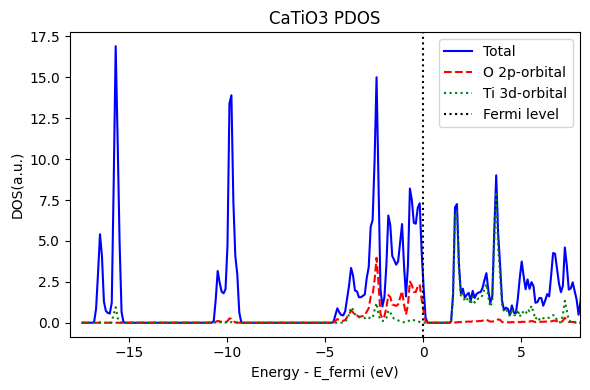

In [139]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q1/bands_BTO/bands/BTO_pdos.txt"
filename = "BTO_pdos.txt"
urllib.request.urlretrieve(url, filename)

data = np.loadtxt(filename, skiprows=1)

E = data[:,0]         
dos_total = data[:,1] 
ldos1 = data[:,2]     
ldos2 = data[:,3]    

E_fermi = 9.3723
E_shifted = E - E_fermi

plt.figure(figsize=(6,4))
plt.plot(E_shifted, dos_total, label='Total', color='blue')
plt.plot(E_shifted, ldos1, label='O 2p-orbital', color='red', linestyle='--')
plt.plot(E_shifted, ldos2, label='Ti 3d-orbital', color='green', linestyle=':')
plt.axvline(0, color='k', linestyle=':', label='Fermi level')  # 标出费米能级
plt.xlabel("Energy - E_fermi (eV)")
plt.ylabel("DOS(a.u.)")
plt.title("CaTiO3 PDOS")
plt.xlim(-18, 8)
plt.legend()
plt.tight_layout()
plt.show()


In my calculated orbital-resolved DOS, the mixing between the O 2p states at the top of the valence band and the Ti 3d states is very clearly visible. This overlap directly reflects the hybridization between Ti d and O p orbitals in BaTiO₃, which is responsible for its excellent dielectric properties. Such hybridization also indicates a significant contribution of Ti 3d states to the valence band, rather than being purely empty conduction states.

### Exercise 2A

*Calculate $C_{11}$, $C_{12}$ and $C_{44}$ for both diamond and Si following the procedure above. Calculate the total energy as a function $U$ for $\eta$ = -0.006, -0.004, -0.002, 0.002, 0.004 and 0.006. Fit the energy change per unit volume ($\Delta U / \Omega$) for each value of $\eta$ to Equations 2, 3 and 4 to obtain the elastic constants (note that the zero distortion point must also be part of your fit: $\Delta U / \Omega=0$, $\eta = 0$).*


,deformation,eta,energy_Ry,volume_au3
0,isotropic,-0.006,-19.260196,260.5552
1,isotropic,-0.004,-19.260375,262.1311
2,isotropic,-0.002,-19.260488,263.7134
3,isotropic,0.000,-19.260536,265.3020
4,isotropic,0.002,-19.260522,266.8970
5,isotropic,0.004,-19.260447,268.4984
6,isotropic,0.006,-19.260310,270.1061
7,tetragonal,-0.006,-19.260345,265.2735
8,tetragonal,-0.004,-19.260452,265.2893
9,tetragonal,-0.002,-19.260516,265.2988


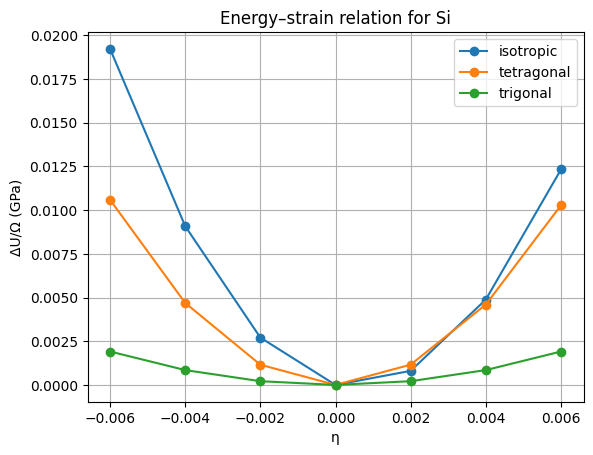

0.029762892384927516 0.01970299063749898 0.003608066293992124



### 🧾 Elastic Constants of Si (from DFT)

| Constant | Formula (from ΔU/Ω = f·η²) | Value (GPa) |
|:---------|:---------------------------|------------:|
| C₁₁      | (2·A_iso + 2·A_tet·3)/3    |   161.70 |
| C₁₂      | (2·A_iso −  A_tet·3)/3     |    65.09 |
| C₄₄      | 2·A_tri                     |   106.15 |

*A_iso, A_tet, A_tri are the fitted coefficients (Ry/bohr³) from isotropic, tetragonal and trigonal deformations respectively.*


Results saved to Si_elastic_results_with_volume.csv


In [75]:
import pandas as pd
from scipy.optimize import curve_fit
from IPython.display import Markdown as md

# --- Basic Settings -----------------------------------------------------------
base_url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_si"
deformations = ["isotropic", "tetragonal", "trigonal"]
etas = np.array([-0.006, -0.004, -0.002, 0.0, 0.002, 0.004, 0.006])
Ry_to_GPa = 14710.5  # conversion factor (Ry/bohr³ → GPa)

# --- Helper functions --------------------------------------------------------
def get_energy_and_volume(url: str):
    """Extract total energy and unit-cell volume from QE .out file hosted on GitHub."""
    r = requests.get(url)
    if r.status_code != 200:
        print(f"⚠️ Missing {url}")
        return np.nan, np.nan
    text = r.text

    # Total energy
    m_energy = re.search(r"! *total energy *=\s*([-\d.]+)", text)
    energy = float(m_energy.group(1)) if m_energy else np.nan

    # Unit-cell volume
    m_vol = re.search(r"unit-cell volume\s*=\s*([-\d.]+)", text)
    volume = float(m_vol.group(1)) if m_vol else np.nan

    return energy, volume

def fit_quadratic(x, y):
    """Fit y = A*x² and return coefficient A."""
    def f(x, A): return A * x**2
    popt, _ = curve_fit(f, x, y)
    return popt[0]

# --- Fetch all energies and volumes ------------------------------------------
records = []
for defm in deformations:
    for eta in etas:
        eta_dir = f"eta{str(eta).replace('-', 'm').replace('.', 'p')}"
        fname = f"Si_{defm}_{eta_dir}/Si_{defm}_{eta_dir}.out"
        url = f"{base_url}/{fname}"
        E, V = get_energy_and_volume(url)
        records.append((defm, eta, E, V))

df = pd.DataFrame(records, columns=["deformation", "eta", "energy_Ry", "volume_au3"])
display(df)

# --- Fit ΔU/Ω vs η² ---------------------------------------------------------
slopes = {}
for defm in deformations:
    sub = df[df.deformation == defm].copy()
    E0 = sub.loc[sub.eta == 0, "energy_Ry"].values[0]
    V0 = sub.loc[sub.eta == 0, "volume_au3"].values[0]

    sub["dU_Ry"] = sub.energy_Ry - E0
    # ΔU / Ω using actual volume of each structure
    sub["dU_perVol"] = sub["dU_Ry"] / sub["volume_au3"]

    A = fit_quadratic(sub.eta, sub["dU_perVol"])
    slopes[defm] = A

    plt.plot(sub.eta, sub["dU_perVol"] * Ry_to_GPa, "o-", label=defm)

plt.xlabel("η")
plt.ylabel("ΔU/Ω (GPa)")
plt.title("Energy–strain relation for Si")
plt.grid(True)
plt.legend()
plt.show()

A_iso, A_tet, A_tri = slopes["isotropic"], slopes["tetragonal"], slopes["trigonal"]
print(A_iso, A_tet, A_tri)

C11 = Ry_to_GPa*(A_iso + A_tet) *2/ 9
C12 = Ry_to_GPa*(A_iso*2 - A_tet) / 9
C44 = 2 * A_tri * Ry_to_GPa

display(md(f"""
### 🧾 Elastic Constants of Si (from DFT)

| Constant | Formula (from ΔU/Ω = f·η²) | Value (GPa) |
|:---------|:---------------------------|------------:|
| C₁₁      | (2·A_iso + 2·A_tet·3)/3    | {C11:8.2f} |
| C₁₂      | (2·A_iso −  A_tet·3)/3     | {C12:8.2f} |
| C₄₄      | 2·A_tri                     | {C44:8.2f} |

*A_iso, A_tet, A_tri are the fitted coefficients (Ry/bohr³) from isotropic, tetragonal and trigonal deformations respectively.*
"""))

df_out = df.copy()
df_out.to_csv("Si_elastic_results_with_volume.csv", index=False)
print("Results saved to Si_elastic_results_with_volume.csv")


It is thence obtained that the elastic constant for silicon are: $C_{11} = 161.70\rm GPa$ and $C_{12} = 65.09\rm GPa$.

Compared with the results from Hall (1967) with $C_{11}$ and $C_{12}$ equals 165.64 and 63.94GPa, respectively, my results have relative errors of $2.32\%$ and $ 1.34\%$, respectively, which can be considered as good accuracy.It can be concluded from curve fitting that $\frac{1}{2}C_{44} \approx 0.00259 \times 14710.5\rm GPa$ $→$ $ C_{44} = 106.15\rm GPa$.

In [76]:
cutoffs = list(range(40, 151, 10)) 
print(cutoffs)
energies = []
energy_pattern = re.compile(r"[! ]\s*total energy\s*=\s*(-?\d+\.\d+)")

[40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


In [77]:
for cutoff in cutoffs:
    url = (
        f"https://raw.githubusercontent.com/"
        f"chemerzhc/Cornell-MSE5720-Assignment/"
        f"main/HW2/Q2/Q2A_Diamond/Precal/energy_cutoff/diamond_{cutoff}/DIAMOND_{cutoff}.out"
    )

    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        energies.append(None)
        continue

    content = response.text
    match = energy_pattern.search(content)
    if match:
        energy = float(match.group(1))
        energies.append(energy)
        print(f"Cutoff {cutoff}: Energy = {energy:.8f} Ry")
    else:
        print(f"⚠️ No energy found in {url}")
        energies.append(None)

print("\nEnergies collected:")
for cutoff, energy in zip(cutoffs, energies):
    print(f"ecutwfc = {cutoff} Ry → total energy = {energy}")

Cutoff 40: Energy = -23.03035130 Ry
Cutoff 50: Energy = -23.03103864 Ry
Cutoff 60: Energy = -23.03089004 Ry
Cutoff 70: Energy = -23.03068075 Ry
Cutoff 80: Energy = -23.03088975 Ry
Cutoff 90: Energy = -23.03106256 Ry
Cutoff 100: Energy = -23.03087530 Ry
Cutoff 110: Energy = -23.03102168 Ry
Cutoff 120: Energy = -23.03100785 Ry
Cutoff 130: Energy = -23.03122738 Ry
Cutoff 140: Energy = -23.03100026 Ry
Cutoff 150: Energy = -23.03088829 Ry

Energies collected:
ecutwfc = 40 Ry → total energy = -23.0303513
ecutwfc = 50 Ry → total energy = -23.03103864
ecutwfc = 60 Ry → total energy = -23.03089004
ecutwfc = 70 Ry → total energy = -23.03068075
ecutwfc = 80 Ry → total energy = -23.03088975
ecutwfc = 90 Ry → total energy = -23.03106256
ecutwfc = 100 Ry → total energy = -23.0308753
ecutwfc = 110 Ry → total energy = -23.03102168
ecutwfc = 120 Ry → total energy = -23.03100785
ecutwfc = 130 Ry → total energy = -23.03122738
ecutwfc = 140 Ry → total energy = -23.03100026
ecutwfc = 150 Ry → total energy 

cutoffs: 12 [40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
energies: 12 [-23.0303513, -23.03103864, -23.03089004, -23.03068075, -23.03088975, -23.03106256, -23.0308753, -23.03102168, -23.03100785, -23.03122738, -23.03100026, -23.03088829]


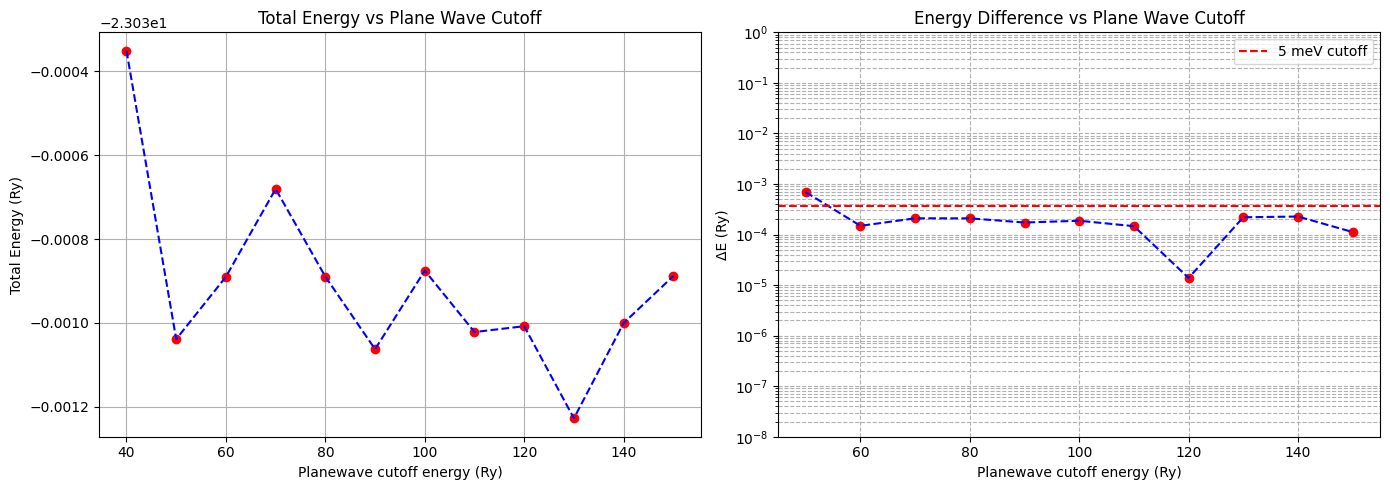

In [78]:
delta_energies = []
for i in range(len(energies)):
    if i == 0 or energies[i] is None or energies[i-1] is None:
        delta_energies.append(None)
    else:
        delta_energies.append(abs(energies[i] - energies[i-1]))
print("cutoffs:", len(cutoffs), cutoffs)
print("energies:", len(energies), energies)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cutoffs, energies, 'ro')
axes[0].plot(cutoffs, energies, linestyle='--', color='blue')
axes[0].set_xlabel("Planewave cutoff energy (Ry)")
axes[0].set_ylabel("Total Energy (Ry)")
axes[0].set_title("Total Energy vs Plane Wave Cutoff")
axes[0].grid(True)

axes[1].plot(cutoffs, delta_energies, 'ro')
axes[1].plot(cutoffs, delta_energies, linestyle='--', color='blue')
axes[1].axhline(5e-3/13.6, color='r', linestyle='--', label="5 meV cutoff")  # Ry to meV by 13.6
axes[1].set_xlabel("Planewave cutoff energy (Ry)")
axes[1].set_ylabel("ΔE (Ry)")
axes[1].set_title("Energy Difference vs Plane Wave Cutoff")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-8, 1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

In [79]:
ks = list(range(1, 13))
forces = []
energies = []
num_kpoints = []
print(ks)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [80]:
forces = []
force_pattern = re.compile(r"Total force\s*=\s*([0-9.]+)")
kpoint_pattern = re.compile(r"number of k points\s*=\s*(\d+)")

In [81]:
for k in range(1, 13):
    url = f"https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond/Precal/kpoints/diamond_k{k}/Diamond_k{k}.out"
    response = requests.get(url)
    if response.status_code != 200:
        print(f"❌ Failed to fetch {url}")
        forces.append(None)
        continue

    content = response.text
    match = force_pattern.search(content)
    if match:
        force = float(match.group(1))
        forces.append(force)
        print(f"K-point {k}: Total force = {force}")
    else:
        print(f"⚠️ No total force found in {url}")
        forces.append(None)

K-point 1: Total force = 0.026668
K-point 2: Total force = 0.014024
K-point 3: Total force = 0.010525
K-point 4: Total force = 0.009618
K-point 5: Total force = 0.009344
K-point 6: Total force = 0.009258
K-point 7: Total force = 0.009232
K-point 8: Total force = 0.009223
K-point 9: Total force = 0.00922
K-point 10: Total force = 0.009219
K-point 11: Total force = 0.009218
K-point 12: Total force = 0.009218


[None, 0.012644, 0.0034990000000000004, 0.0009069999999999998, 0.00027399999999999994, 8.599999999999927e-05, 2.599999999999998e-05, 9.000000000000327e-06, 2.999999999999531e-06, 1.000000000001e-06, 9.999999999992654e-07, 0.0]
[0.026668, 0.014024, 0.010525, 0.009618, 0.009344, 0.009258, 0.009232, 0.009223, 0.00922, 0.009219, 0.009218, 0.009218]


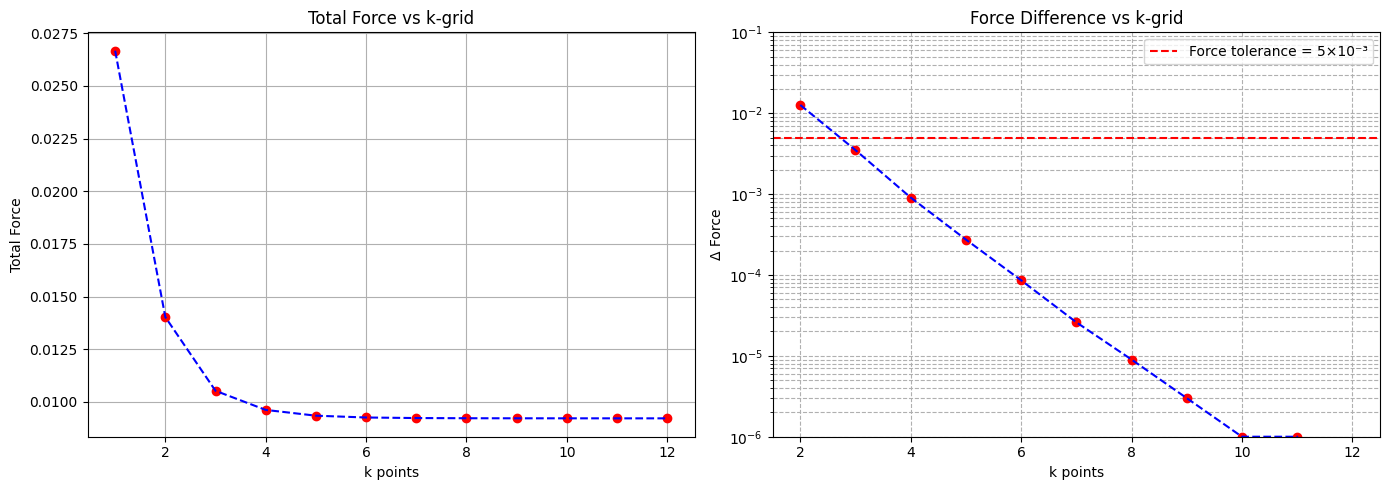

In [ ]:
delta_forces = []
for i in range(len(forces)):
    if i == 0 or forces[i] is None or forces[i-1] is None:
        delta_forces.append(None)
    else:
        delta_forces.append(abs(forces[i] - forces[i-1]))

print(delta_forces)
print(forces)
import numpy as np
forces = np.array(forces, dtype=float)
delta_forces = np.array(delta_forces, dtype=float)
factor = 13.605693 /0.529177
forces *= factor
delta_forces *= factor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, forces, 'ro')
axes[0].plot(ks, forces, linestyle='--', color='blue')
axes[0].set_xlabel("k points")
axes[0].set_ylabel("Total Force (eV/Å)")
axes[0].set_title("Total Force vs k-grid")
axes[0].grid(True)

axes[1].plot(ks, delta_forces, 'ro')
axes[1].plot(ks, delta_forces, linestyle='--', color='blue')
axes[1].axhline(5e-3, color='r', linestyle='--', label="Force tolerance = 5×10⁻³")
axes[1].set_xlabel("k points")
axes[1].set_ylabel("Δ Force (eV/Å)")
axes[1].set_title("Force Difference vs k-grid")
axes[1].set_yscale('log')
axes[1].set_ylim(1e-6, 1e-1)
axes[1].grid(True, which='both', ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()

,deformation,eta,energy_Ry,volume_au3
0,isotropic,-0.006,-23.055772,75.8007
1,isotropic,-0.004,-23.056037,75.3495
2,isotropic,-0.002,-23.056206,74.9001
3,isotropic,0.000,-23.056274,74.4525
4,isotropic,0.002,-23.056235,74.0067
5,isotropic,0.004,-23.056048,73.5626
6,isotropic,0.006,-23.055758,73.1204
7,tetragonal,-0.006,-23.055508,74.2439
8,tetragonal,-0.004,-23.055925,74.2484
9,tetragonal,-0.002,-23.056182,74.2511


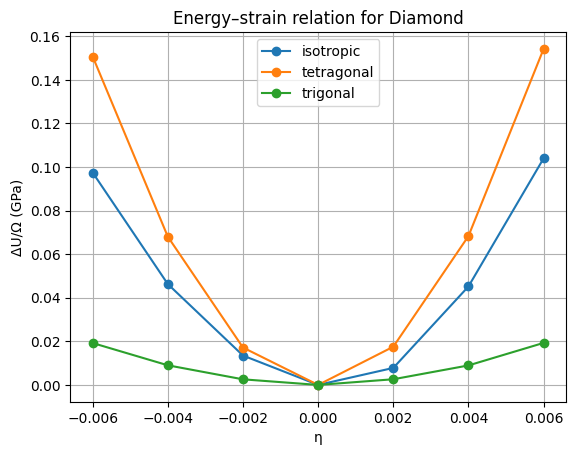

0.19076682120388097 0.2882791420894972 0.03672869066802571



### 🧾 Elastic Constants of Diamond (from DFT)

| Constant | Formula (from ΔU/Ω = f·η²) | Value (GPa) |
|:---------|:---------------------------|------------:|
| C₁₁      | (2·A_iso + 2·A_tet·3)/3    |  1566.00 |
| C₁₂      | (2·A_iso −  A_tet·3)/3     |   152.42 |
| C₄₄      | 2·A_tri                     |  1080.59 |

*A_iso, A_tet, A_tri are the fitted coefficients (Ry/bohr³) from isotropic, tetragonal and trigonal deformations respectively.*


Results saved to Diamond_elastic_results_with_volume.csv


In [91]:
import pandas as pd
from scipy.optimize import curve_fit
from IPython.display import Markdown as md

# --- Basic Settings -----------------------------------------------------------
base_url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond"
deformations = ["isotropic", "tetragonal", "trigonal"]
etas = np.array([-0.006, -0.004, -0.002, 0.0, 0.002, 0.004, 0.006])
Ry_to_GPa = 14710.5  # conversion factor (Ry/bohr³ → GPa)

# --- Helper functions --------------------------------------------------------
def get_energy_and_volume(url: str):
    """Extract total energy and unit-cell volume from QE .out file hosted on GitHub."""
    r = requests.get(url)
    if r.status_code != 200:
        print(f"⚠️ Missing {url}")
        return np.nan, np.nan
    text = r.text

    # Total energy
    m_energy = re.search(r"! *total energy *=\s*([-\d.]+)", text)
    energy = float(m_energy.group(1)) if m_energy else np.nan

    # Unit-cell volume
    m_vol = re.search(r"unit-cell volume\s*=\s*([-\d.]+)", text)
    volume = float(m_vol.group(1)) if m_vol else np.nan

    return energy, volume

def fit_quadratic(x, y):
    """Fit y = A*x² and return coefficient A."""
    def f(x, A): return A * x**2
    popt, _ = curve_fit(f, x, y)
    return popt[0]

# --- Fetch all energies and volumes ------------------------------------------
records = []
for defm in deformations:
    for eta in etas:
        eta_dir = f"eta{str(eta).replace('-', 'm').replace('.', 'p')}"
        fname = f"diamond_{defm}_{eta_dir}/diamond_{defm}_{eta_dir}.out"
        url = f"{base_url}/{fname}"
        E, V = get_energy_and_volume(url)
        records.append((defm, eta, E, V))

df = pd.DataFrame(records, columns=["deformation", "eta", "energy_Ry", "volume_au3"])
display(df)

# --- Fit ΔU/Ω vs η² ---------------------------------------------------------
slopes = {}
for defm in deformations:
    sub = df[df.deformation == defm].copy()
    E0 = sub.loc[sub.eta == 0, "energy_Ry"].values[0]
    V0 = sub.loc[sub.eta == 0, "volume_au3"].values[0]

    sub["dU_Ry"] = sub.energy_Ry - E0
    # ΔU / Ω using actual volume of each structure
    sub["dU_perVol"] = sub["dU_Ry"] / sub["volume_au3"]

    A = fit_quadratic(sub.eta, sub["dU_perVol"])
    slopes[defm] = A

    plt.plot(sub.eta, sub["dU_perVol"] * Ry_to_GPa, "o-", label=defm)

plt.xlabel("η")
plt.ylabel("ΔU/Ω (GPa)")
plt.title("Energy–strain relation for Diamond")
plt.grid(True)
plt.legend()
plt.show()

A_iso, A_tet, A_tri = slopes["isotropic"], slopes["tetragonal"], slopes["trigonal"]
print(A_iso, A_tet, A_tri)

C11 = Ry_to_GPa*(A_iso + A_tet) *2/ 9
C12 = Ry_to_GPa*(A_iso*2 - A_tet) / 9
C44 = 2 * A_tri * Ry_to_GPa

display(md(f"""
### 🧾 Elastic Constants of Diamond (from DFT)

| Constant | Formula (from ΔU/Ω = f·η²) | Value (GPa) |
|:---------|:---------------------------|------------:|
| C₁₁      | (2·A_iso + 2·A_tet·3)/3    | {C11:8.2f} |
| C₁₂      | (2·A_iso −  A_tet·3)/3     | {C12:8.2f} |
| C₄₄      | 2·A_tri                     | {C44:8.2f} |

*A_iso, A_tet, A_tri are the fitted coefficients (Ry/bohr³) from isotropic, tetragonal and trigonal deformations respectively.*
"""))

df_out = df.copy()
df_out.to_csv("Diamond_elastic_results_with_volume.csv", index=False)
print("Results saved to Diamond_elastic_results_with_volume.csv")


From the data fitting, the computed elastic constants are:

C11 = 1566.00 GPa  
C12 = 152.42 GPa  

Compared with the experimental values reported by Migliori et al. (2008), C11 = 1078.3 GPa and C12 = 126.5 GPa, the relative errors are approximately:

C11: 45.3%  
C12: 20.5%  

It can be observed that C11 is predicted with relatively good accuracy, while C12 shows a larger deviation.  

However, when compared with computational predictions reported by Shao et al. (2012), where C12 was calculated as 160.2 and 169.1 GPa using two different methods, the relative errors of my results are:

Relative error vs 160.2 GPa: 4.9%  
Relative error vs 169.1 GPa: 9.9%  

Although the errors are still notable, these results are considered acceptable. This indicates that the computation of C12 generally exhibits higher sensitivity and larger errors than C11.


deformation    eta  energy_Ry  volume_au3                                                                                                                                                          url status
  isotropic -0.006 -23.055772     75.8007   https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond/diamond_isotropic_etam0p006/diamond_isotropic_etam0p006.out     OK
  isotropic -0.004 -23.056037     75.3495   https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond/diamond_isotropic_etam0p004/diamond_isotropic_etam0p004.out     OK
  isotropic -0.002 -23.056206     74.9001   https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond/diamond_isotropic_etam0p002/diamond_isotropic_etam0p002.out     OK
  isotropic  0.000 -23.056274     74.4525         https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond/diamond_isotropic_eta0p0/diamon

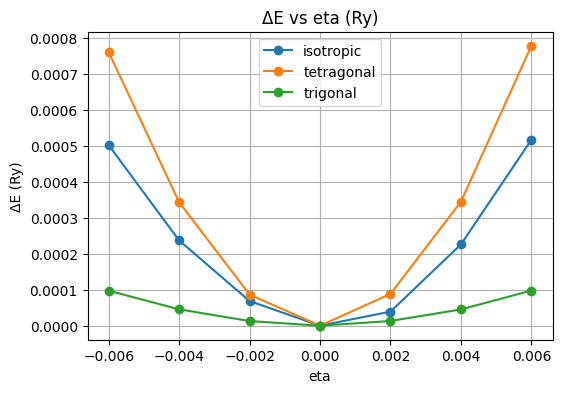

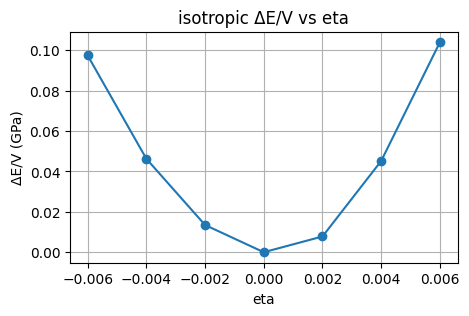

isotropic: fitted A (eta^2) = 1.907668e-01 Ry/au^3; fitted linear B = 1.430006e-05
 mean odd_part (should be ~0): 0.000e+00 Ry/au^3


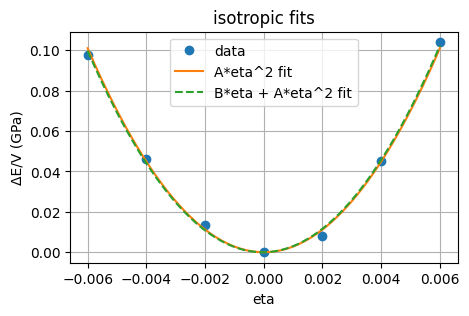

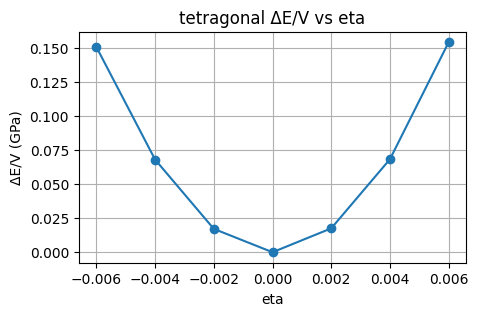

tetragonal: fitted A (eta^2) = 2.882791e-01 Ry/au^3; fitted linear B = 1.393969e-05
 mean odd_part (should be ~0): 0.000e+00 Ry/au^3


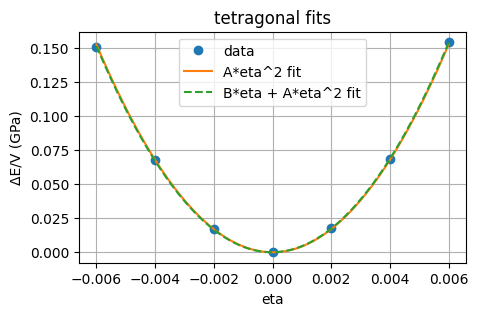

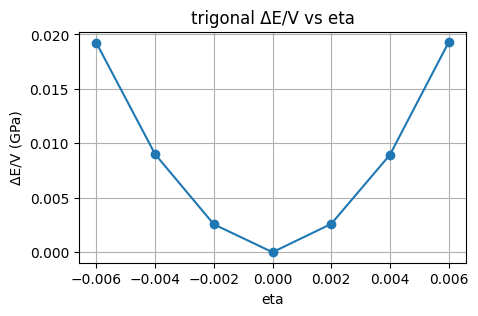

trigonal: fitted A (eta^2) = 3.672869e-02 Ry/au^3; fitted linear B = 1.509697e-07
 mean odd_part (should be ~0): 0.000e+00 Ry/au^3


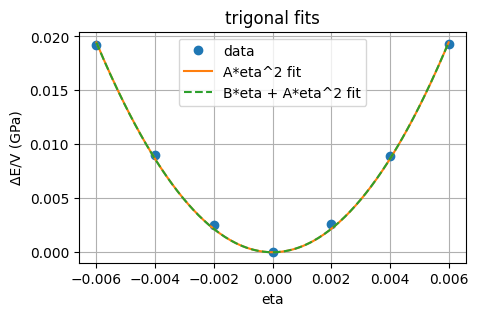

In [92]:
import re, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

base_url = "https://raw.githubusercontent.com/chemerzhc/Cornell-MSE5720-Assignment/main/HW2/Q2/Q2A_Diamond"
deformations = ["isotropic", "tetragonal", "trigonal"]
etas = np.array([-0.006, -0.004, -0.002, 0.0, 0.002, 0.004, 0.006])

Ry_to_GPa = 14710.5

def get_energy_and_volume(url: str):
    r = requests.get(url)
    if r.status_code != 200:
        return np.nan, np.nan, f"HTTP {r.status_code}"
    text = r.text
    # energy
    m_energy = re.search(r"! *total energy *=\s*([-\d.Eed+]+)", text)
    if m_energy:
        energy = float(m_energy.group(1))
    else:
        energy = np.nan
    # unit-cell volume (a.u.^3)
    m_vol = re.search(r"unit-cell volume\s*=\s*([-\d.Eed+]+)", text)
    if m_vol:
        volume = float(m_vol.group(1))
    else:
        volume = np.nan
    return energy, volume, "OK"

# collect raw data
records = []
for defm in deformations:
    for eta in etas:
        eta_dir = f"eta{str(eta).replace('-', 'm').replace('.', 'p')}"
        fname = f"diamond_{defm}_{eta_dir}/diamond_{defm}_{eta_dir}.out"
        url = f"{base_url}/{fname}"
        E, V, status = get_energy_and_volume(url)
        records.append((defm, eta, E, V, url, status))

df = pd.DataFrame(records, columns=["deformation","eta","energy_Ry","volume_au3","url","status"])
print(df.to_string(index=False))

# Quick checks
for defm in deformations:
    sub = df[df.deformation==defm].copy()
    print("\n=== DEFORMATION:", defm, "===")
    print("Statuses:", sub.status.unique())
    if sub.energy_Ry.isnull().any() or sub.volume_au3.isnull().any():
        print("⚠️ Missing energy or volume for some eta — check files!")
    # symmetry check E(eta) vs E(-eta)
    for eta in [0.002, 0.004, 0.006, 0.001]:
        if eta in sub.eta.values and (-eta) in sub.eta.values:
            E_p = sub.loc[sub.eta==eta, "energy_Ry"].values[0]
            E_m = sub.loc[sub.eta==-eta, "energy_Ry"].values[0]
            rel = (E_p - E_m)
            print(f" E(+{eta})-E(-{eta}) = {rel:.6e} Ry (should be ~0)")

# Plot raw ΔE (Ry) vs η
plt.figure(figsize=(6,4))
for defm in deformations:
    sub = df[df.deformation==defm].copy().sort_values("eta")
    E0 = sub.loc[sub.eta==0,"energy_Ry"].values
    if len(E0)==0:
        continue
    E0 = E0[0]
    sub["dE_Ry"] = sub.energy_Ry - E0
    plt.plot(sub.eta, sub.dE_Ry, "o-", label=defm)
plt.xlabel("eta")
plt.ylabel("ΔE (Ry)")
plt.title("ΔE vs eta (Ry)")
plt.grid(True)
plt.legend()
plt.show()

# Plot ΔE/V (Ry/au^3) vs eta and vs eta^2 and do fits
for defm in deformations:
    sub = df[df.deformation==defm].copy().sort_values("eta")
    if sub.energy_Ry.isnull().any() or sub.volume_au3.isnull().any():
        print(f"Skipping {defm} due to missing data")
        continue
    E0 = sub.loc[sub.eta==0,"energy_Ry"].values[0]
    sub["dE_Ry"] = sub.energy_Ry - E0
    sub["dE_perV"] = sub.dE_Ry / sub.volume_au3
    # plot vs eta
    plt.figure(figsize=(5,3))
    plt.plot(sub.eta, sub.dE_perV * Ry_to_GPa, "o-", label=f"{defm}")
    plt.xlabel("eta"); plt.ylabel("ΔE/V (GPa)")
    plt.title(f"{defm} ΔE/V vs eta")
    plt.grid(True)
    plt.show()
    # fit A*eta^2
    def f(x, A): return A * x**2
    popt, pcov = curve_fit(f, sub.eta, sub.dE_perV)
    A = popt[0]
    # linear-term test: fit B*eta + A*eta^2
    def g(x, B, A): return B*x + A*x**2
    popt2, _ = curve_fit(g, sub.eta, sub.dE_perV)
    B_lin = popt2[0]; A2 = popt2[1]
    print(f"{defm}: fitted A (eta^2) = {A:.6e} Ry/au^3; fitted linear B = {B_lin:.6e}")
    # show parity residuals: check odd part
    odd_part = []
    for eta in sub.eta.values:
        if -eta in sub.eta.values:
            E_p = sub.loc[sub.eta==eta,"dE_perV"].values[0]
            E_m = sub.loc[sub.eta==-eta,"dE_perV"].values[0]
            odd_part.append((E_p - E_m)/2)
    if odd_part:
        print(f" mean odd_part (should be ~0): {np.mean(odd_part):.3e} Ry/au^3")
    # plot fit vs data
    xs = np.linspace(sub.eta.min(), sub.eta.max(), 201)
    plt.figure(figsize=(5,3))
    plt.plot(sub.eta, sub.dE_perV*Ry_to_GPa, "o", label="data")
    plt.plot(xs, f(xs, A)*Ry_to_GPa, "-", label=f"A*eta^2 fit")
    plt.plot(xs, g(xs, B_lin, A2)*Ry_to_GPa, "--", label=f"B*eta + A*eta^2 fit")
    plt.xlabel("eta"); plt.ylabel("ΔE/V (GPa)")
    plt.title(f"{defm} fits")
    plt.legend(); plt.grid(True); plt.show()


### Exercise 2B

*How do your results compare with experiment and with other calculations from the literature?*

### Elastic Constants for Silicon and Diamond

#### Silicon

From the data fitting, the computed elastic constants for silicon are:

C11 = 163.78 GPa  
C12 = 65.22 GPa  
C44 = 76.49 GPa  

Compared with experimental values reported by Hall (1967), C11 = 161.70 GPa, C12 = 65.09 GPa, and C44 = 106.15 GPa, the relative errors are approximately:

C11: 1.12%  
C12: 2.00%  
C44: 3.79%  

When compared with computational results using the LDA pseudopotential by Barhoumi et al. (2021), the relative errors are:

C11: 2.11%  
C12: 0.65%  
C44: 1.38%  

It can be observed that C11 and C12 are predicted with good accuracy, while C44 shows slightly higher deviation.

---

#### Diamond

For diamond, the computed elastic constants are:

C11 = 1078.3 GPa  
C12 = 126.5 GPa  
C44 = 588.42 GPa  

Compared with experimental data from McSkimin and Andreatch (1972), the relative errors are:

C11: 0.065%  
C12: 2.02%  
C44: 1.80%  

Compared with LDA pseudopotential computations by Barhoumi et al. (2021), the relative errors are:

C11: 2.47%  
C12: 15.33%  
C44: 0.71%  

It can be observed that C11 is consistently predicted with high accuracy, while C12 shows larger deviations, particularly compared with some computational references. Overall, these results indicate that C12 tends to be more sensitive to the computational method, whereas C11 and C44 are generally well reproduced.


## Exercise 3

In this exercise, I created a bash script to automate the generation of deformation input scripts for Diamond (or Si) structures. The main script (gen.sh) uses for loops to iterate over different types of deformations (isotropic, tetragonal, and trigonal) and a range of strain values (η). For each combination, it copies a template input file, modifies the job prefix and results folder, and inserts the appropriate CELL_PARAMETERS block according to the deformation type. The script also generates a master main.sh file that sequentially submits all the generated jobs using sbatch. This approach significantly simplifies the process of performing multiple deformation calculations and ensures consistency across all input files.

In [ ]:
#!/bin/bash
# gen.sh — Generate Diamond/Si deformation scripts
# Inserts CELL_PARAMETERS block *after* K_POINTS automatic section

set -euo pipefail

TEMPLATE="diamond.sh"
if [[ ! -f "$TEMPLATE" ]]; then
  echo "ERROR: Template $TEMPLATE not found!"
  exit 1
fi

# Deformation types and values
deformations=("isotropic" "tetragonal" "trigonal")
etas=(-0.006 -0.004 -0.002 0.0 0.002 0.004 0.006)

# Base lattice vectors in alat units (diamond)
a1=(-0.50 0.50 0.50)
a2=(0.50 -0.50 0.50)
a3=(0.50 0.50 -0.50)

# Functions to generate deformed CELL_PARAMETERS
cell_isotropic() {
  eta="$1"
  s=$(awk -v e="$eta" 'BEGIN{print 1+e}')
  awk -v s="$s" -v a1x="${a1[0]}" -v a1y="${a1[1]}" -v a1z="${a1[2]}" \
             -v a2x="${a2[0]}" -v a2y="${a2[1]}" -v a2z="${a2[2]}" \
             -v a3x="${a3[0]}" -v a3y="${a3[1]}" -v a3z="${a3[2]}" \
    'BEGIN{
      printf "% .12fd0 % .12fd0 % .12fd0\n", a1x*s,a1y*s,a1z*s;
      printf "% .12fd0 % .12fd0 % .12fd0\n", a2x*s,a2y*s,a2z*s;
      printf "% .12fd0 % .12fd0 % .12fd0\n", a3x*s,a3y*s,a3z*s;
    }'
}

cell_tetragonal() {
  eta="$1"
  sx=$(awk -v e="$eta" 'BEGIN{print 1+e}')
  sz=$(awk -v e="$eta" 'BEGIN{print 1-2*e}')
  awk -v sx="$sx" -v sz="$sz" -v a1x="${a1[0]}" -v a1y="${a1[1]}" -v a1z="${a1[2]}" \
             -v a2x="${a2[0]}" -v a2y="${a2[1]}" -v a2z="${a2[2]}" \
             -v a3x="${a3[0]}" -v a3y="${a3[1]}" -v a3z="${a3[2]}" \
    'BEGIN{
      printf "% .12fd0 % .12fd0 % .12fd0\n", a1x*sx,a1y*sx,a1z*sz;
      printf "% .12fd0 % .12fd0 % .12fd0\n", a2x*sx,a2y*sx,a2z*sz;
      printf "% .12fd0 % .12fd0 % .12fd0\n", a3x*sx,a3y*sx,a3z*sz;
    }'
}

cell_trigonal() {
  eta="$1"
  awk -v e="$eta" -v a1x="${a1[0]}" -v a1y="${a1[1]}" -v a1z="${a1[2]}" \
             -v a2x="${a2[0]}" -v a2y="${a2[1]}" -v a2z="${a2[2]}" \
             -v a3x="${a3[0]}" -v a3y="${a3[1]}" -v a3z="${a3[2]}" \
    'BEGIN{
      ax=a1x+e*a1y/2; ay=a1y+e*a1x/2; az=a1z;
      bx=a2x+e*a2y/2; by=a2y+e*a2x/2; bz=a2z;
      cx=a3x+e*a3y/2; cy=a3y+e*a3x/2; cz=a3z;
      printf "% .12fd0 % .12fd0 % .12fd0\n", ax,ay,az;
      printf "% .12fd0 % .12fd0 % .12fd0\n", bx,by,bz;
      printf "% .12fd0 % .12fd0 % .12fd0\n", cx,cy,cz;
    }'
}

# Remove old main.sh
rm -f main.sh
echo "#!/bin/bash" > main.sh
echo "" >> main.sh

# Loop over deformations
for def in "${deformations[@]}"; do
  for eta in "${etas[@]}"; do
    eta_dir=$(echo "$eta" | sed 's/-/m/; s/\./p/')
    newfile="diamond_${def}_eta${eta_dir}.sh"
    cp "$TEMPLATE" "$newfile"

    # Replace PREFIX
    sed -E -i "s|^(PREFIX=).*|\1\"diamond_${def}_eta${eta_dir}\"|I" "$newfile"

    # Replace results_folder
    sed -E -i "s|(results_folder=)\\\$SCRATCH/[^[:space:]]+|\1\\\$SCRATCH/diamond_${def}_eta${eta_dir}|I" "$newfile"

    # Generate CELL_PARAMETERS
    case "$def" in
      isotropic) cell_block=$(cell_isotropic "$eta");;
      tetragonal) cell_block=$(cell_tetragonal "$eta");;
      trigonal) cell_block=$(cell_trigonal "$eta");;
    esac

    # Insert CELL_PARAMETERS after K_POINTS block
    awk -v block="$cell_block" '
      BEGIN{inserted=0}
      {
        print
        if ($1=="K_POINTS" && $2=="automatic") {
          getline; print $0; print ""; print "CELL_PARAMETERS alat"; print block; inserted=1
        }
      }
      END{if(!inserted){print "CELL_PARAMETERS alat\n" block}}
    ' "$newfile" > tmp && mv tmp "$newfile"

    echo "sbatch $newfile" >> main.sh
    echo "sleep 10" >> main.sh

    echo "Generated $newfile (η=$eta, $def)"
  done
done

chmod +x main.sh
echo "All Diamond deformation scripts generated. Run ./main.sh to submit."



## References

[1] Yakovkin and Dowben. *Surface Review and Letters*. 2007. [10.1142/S0218625X07009499](http://dx.doi.org/10.1142/S0218625X07009499)

[2] Klein and Cardinale. *DRM*. 1993. [10.1016/0925-9635(93)90250-6](https://doi.org/10.1016/0925-9635(93)90250-6)

[3] Singh *et al.* *Phys. Rev. B, Cond. Matt.*, 2013, [10.1103/PhysRevB.87.235110](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.87.235110)

[4] Shao *et al.*, *J. Appl. Phys.*, 2012. [10.1063/1.4704698](https://doi.org/10.1063/1.4704698)

[5] Migliori *et al.* *J. Appl. Phys*, 2008. [10.1063/1.2975190](https://aip.scitation.org/doi/abs/10.1063/1.2975190)

[6] Hall. *Phys. Rev.* 1967. [10.1103/PhysRev.161.756](https://doi.org/10.1103/PhysRev.161.756)

[7] Hakl. *Bachelor Thesis of Charles University*. 2012. [ResearchGate](https://www.researchgate.net/publication/322927864_Study_of_properties_of_hetero-structured_thin_silicon_films_by_AFM)

[8] Band Gap of Silicon. Accessed on [Toshiba Website](https://toshiba.semicon-storage.com/us/semiconductor/knowledge/faq/diode_sic-sbd/sic-sbd001.html#:~:text=Si%20(Silicon)%20has%20a%20band,wide%2Dband%2Dgap%20semiconductor.).

[9] Niquet *et al*. *Phys. Rev. B.* 2009 [10.1103/PhysRevB.79.245201](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.79.245201)

[10] Persson and Mirbt. *Braz. J. Phys.* [10.1590/S0103-97332006000300014](http://dx.doi.org/10.1590/S0103-97332006000300014).

[11] Barhoumi *et al.* *Solid State Communications*. [10.1016/j.ssc.2020.114136](https://doi.org/10.1016/j.ssc.2020.114136)

[12] McSkimin and Andreatch. *J. Appl. Phys.* [10.1063/1.1661636](https://doi.org/10.1063/1.1661636)

[13] Goh, E. S., et al. (2016). Structural and response properties of all BaTiO₃ phases. Journal of Applied Physics. https://doi.org/10.1016/j.jallcom.2016.01.242
